In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Training with both FFE data and Warehouse data with 2 classes

## Import Libraries

In [2]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg19 import preprocess_input

from tensorflow.keras.models import Model
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, make_scorer
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import pandas as pd
import numpy as np
import joblib
import os

# Without Augmentation

## Create DataFrame

for Chanos Chanos - Highly Fresh, Chanos Chanos - Fresh, Chanos Chanos - Not Fresh

In [3]:
def create_df(dataset_folder):
    class_dirs = os.listdir(dataset_folder)

    # Determine the freshness category based on folder name
    data = []
    for class_dir in class_dirs:
        # Determine the freshness category based on folder name
        if '- Highly Fresh' in class_dir:
            freshness_label = 'Good'
        elif '- Fresh' in class_dir:
            freshness_label = 'Good'
        elif '- Not Fresh' in class_dir:
            freshness_label = 'Bad'
        else:
            continue

        # List all image files in the class directory
        image_files = os.listdir(os.path.join(dataset_folder, class_dir))

        for img_name in image_files:
            img_path = os.path.join(dataset_folder, class_dir, img_name)
            data.append((img_path, freshness_label))

    df = pd.DataFrame(data, columns=['img_path', 'class_label'])
    return df

In [4]:
class_mapping = {'Good': 1, 'Bad': 0}

for Highly Fresh, Fresh, Not Fresh folders

 and for good n bad folders



In [20]:
def create_df2(dataset_folder):
    class_dirs = os.listdir(dataset_folder)
    data = []
    for class_dir in class_dirs:
        # Determine the freshness category based on folder name
        if 'good'==class_dir.lower():
            freshness_label = 'Good'
        elif 'bad'==class_dir.lower():
            freshness_label = 'Bad'
        elif 'fresh'==class_dir.lower():
            freshness_label = 'Good'
        elif 'not fresh'==class_dir.lower():
            freshness_label = 'Bad'
        else:
            continue

        image_files = os.listdir(os.path.join(dataset_folder, class_dir))
        for img_name in image_files:
            img_path = os.path.join(dataset_folder, class_dir, img_name)
            data.append((img_path, freshness_label))
    df = pd.DataFrame(data, columns=['img_path', 'class_label'])
    return df

## Load the VGG19 model pre-trained on ImageNet

In [5]:
vgg19 = VGG19(weights='imagenet')

574710816/574710816 [==============================] - 11s 0us/step


In [6]:
model = Model(inputs=vgg19.input, outputs=vgg19.get_layer('fc2').output)

In [7]:
def extract_features(img_paths, model):
    # Create a model that outputs activations from the penultimate layer (fc2)
    model = Model(inputs=vgg19.input, outputs=vgg19.get_layer('fc2').output)
    features = []
    for img_path in tqdm(img_paths):
        img = image.load_img(img_path, target_size=(224, 224))
        img_data = image.img_to_array(img)
        img_data = np.expand_dims(img_data, axis=0)
        img_data = preprocess_input(img_data)
        fc2_features = model.predict(img_data, verbose=0)
        features.append(fc2_features.flatten())
    return np.array(features)

In [8]:
def prepare_data(df):
    X = extract_features(df['img_path'].tolist(), model)
    y = df['class_label'].map(class_mapping).values
    return X, y

In [9]:
def save_model_and_scaler(model, scaler, model_name):
    joblib.dump(model, f'{model_name}_model.pkl')
    joblib.dump(scaler, f'{model_name}_scaler.pkl')

def load_model_and_scaler(model_name):
    model = joblib.load(f'{model_name}_model.pkl')
    scaler = joblib.load(f'{model_name}_scaler.pkl')
    return model, scaler

In [10]:
def evaluate_model(y_true, y_pred, class_names, model_name):
    print(classification_report(y_true, y_pred, target_names=class_names))
    print("Accuracy:", accuracy_score(y_true, y_pred))

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

In [11]:
# Custom scoring function for classification report
def classification_report_with_accuracy_score(y_true, y_pred):
    print(classification_report(y_true, y_pred, target_names=class_mapping.keys()))
    return accuracy_score(y_true, y_pred)


def perform_cv(classification_model, X, y):
    # Define the cross-validation strategy
    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scaler = StandardScaler()

    # Cross-validate the model
    results = cross_validate(
        classification_model, scaler.fit_transform(X), y, cv=skf, scoring={
        'accuracy': make_scorer(classification_report_with_accuracy_score)},
        return_train_score=True)

    # Print cross-validation results
    print(f"Train Accuracy: {results['train_accuracy'].mean():.4f} ± {results['train_accuracy'].std():.4f}")
    print(f"Test Accuracy: {results['test_accuracy'].mean():.4f} ± {results['test_accuracy'].std():.4f}")

In [12]:
def train_knn(X_train, y_train, cv=False):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    knn = KNeighborsClassifier(n_neighbors=10,
                               weights='uniform',
                               metric='euclidean')
    if cv:
        perform_cv(knn, X_train, y_train)
    knn.fit(X_train_scaled, y_train)
    return knn, scaler

def train_svm(X_train, y_train, cv=False):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    svm = SVC(C=1.0, kernel='rbf', gamma='auto',
              tol=0.0001, max_iter=1000)
    if cv:
        perform_cv(svm, X_train, y_train)
    svm.fit(X_train_scaled, y_train)
    return svm, scaler

def train_ann(X_train, y_train, cv=False):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    ann = MLPClassifier(hidden_layer_sizes=(100,),
                        activation='relu', solver='adam',
                        alpha=0.0001, max_iter=500,
                        random_state=42)
    if cv:
        perform_cv(ann, X_train, y_train)
    ann.fit(X_train_scaled, y_train)
    return ann, scaler

def train_lr(X_train, y_train, cv=False):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    lr = LogisticRegression(penalty='l1', C=1.0,
                            solver='saga', tol=0.0001,
                            max_iter=1000)
    if cv:
        perform_cv(lr, X_train, y_train)
    lr.fit(X_train_scaled, y_train)
    return lr, scaler

def train_rf(X_train, y_train, cv=False):
    rf = RandomForestClassifier(n_estimators=500, max_features=5,
                                min_samples_split=5, random_state=42)
    if cv:
        perform_cv(rf, X_train, y_train)
    rf.fit(X_train, y_train)
    return rf

def train_rf_scaled(X_train, y_train, cv=False):
    rf = RandomForestClassifier(n_estimators=500, max_features=5,
                                min_samples_split=5, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    if cv:
        perform_cv(rf, X_train_scaled, y_train)
    rf.fit(X_train_scaled, y_train)
    return rf, scaler

def train_xgb(X_train, y_train, cv=False):
    xgb = XGBClassifier(n_estimators=30, max_depth=3,
                       learning_rate=0.1, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    if cv:
        perform_cv(xgb, X_train, y_train)
    xgb.fit(X_train, y_train)
    return xgb, scaler

In [13]:
def test_model(classification_model, X_unseen, y_unseen):
    model, scaler = load_model_and_scaler(classification_model)
    X_unseen_scaled = scaler.transform(X_unseen)
    y_pred = model.predict(X_unseen_scaled)
    evaluate_model(y_unseen, y_pred, class_mapping.keys(),
                   classification_model.upper())

## Creating DataFrame

In [25]:
dataset_folder = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1'
df1 = create_df(dataset_folder)
df1['class_label'].value_counts()

class_label
Good    3084
Bad     1306
Name: count, dtype: int64

In [26]:
dataset_folder = '/content/drive/MyDrive/Kartik /Mackerel_EYE_TURBIDITY_DATASET/mackerel'
df2 = create_df2(dataset_folder)
df2['class_label'].value_counts()

class_label
Bad     939
Good    843
Name: count, dtype: int64

In [27]:
dataset_folder = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/warehouse_data/cropped_eyes(kartik)/Indian salmon'
df3 = create_df2(dataset_folder)
df3['class_label'].value_counts()

class_label
Good    820
Bad      41
Name: count, dtype: int64

In [28]:
dataset_folder = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/warehouse_data/cropped_eyes(kartik)/Tilapia'
df4 = create_df2(dataset_folder)
df4['class_label'].value_counts()

class_label
Good    523
Bad      25
Name: count, dtype: int64

In [ ]:
combined_df = pd.concat([df1, df2, df3, df4], ignore_index=True)
combined_df

In [ ]:
# prompt: combine df1, df2, df3, df4

import pandas as pd
# Combine all dataframes
combined_df = pd.concat([df1, df2, df3, df4], ignore_index=True)

# Shuffle the combined dataframe
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the value counts of the combined dataframe
print(combined_df['class_label'].value_counts())


In [ ]:
test_df = df.sample(frac=0.2, random_state=42)
train_df = df.drop(test_df.index)
df.shape, test_df.shape, train_df.shape

((4390, 2), (878, 2), (3512, 2))

In [ ]:
model_save_path = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models'
os.makedirs(model_save_path, exist_ok=True)
%cd {model_save_path}

/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models


## Training

In [ ]:
# Prepare data
X, y = prepare_data(train_df)
X.shape, y.shape

100%|██████████| 3512/3512 [1:10:22<00:00,  1.20s/it]


((3512, 4096), (3512,))

In [ ]:
# Train and save KNN model
knn, scaler_knn = train_knn(X, y, cv=True)
save_model_and_scaler(knn, scaler_knn, 'knn')
print('KNN model saved successfully!')

# Train and save SVM model
svm, scaler_svm = train_svm(X, y, cv=True)
save_model_and_scaler(svm, scaler_svm, 'svm')
print('SVM model saved successfully!')

# Train and save ANN model
ann, scaler_ann = train_ann(X, y, cv=True)
save_model_and_scaler(ann, scaler_ann, 'ann')
print('ANN model saved successfully!')

# Train and save LR model
lr, scaler_lr = train_lr(X, y, cv=True)
save_model_and_scaler(lr, scaler_lr, 'lr')
print('LR model saved successfully!')

# Train and save RF model
rf = train_rf(X, y, cv=True)
joblib.dump(rf, 'rf.pkl')
print('RF model saved successfully!')

# Train and save RF model with scaled features
rf, scaler_rf = train_rf_scaled(X, y, cv=True)
save_model_and_scaler(rf, scaler_rf, 'rf_scaled')
print('RF model with scaled features saved successfully!')

# Train and save XGB model
xgb, scaler_xgb = train_xgb(X, y, cv=True)
save_model_and_scaler(xgb, scaler_xgb, 'xgb')
print('XGB model saved successfully!')

print('All models saved successfully!')

              precision    recall  f1-score   support

Highly Fresh       0.62      0.49      0.55        71
       Fresh       0.31      0.57      0.40        49
   Not Fresh       0.60      0.32      0.42        56

    accuracy                           0.46       176
   macro avg       0.51      0.46      0.46       176
weighted avg       0.53      0.46      0.47       176

              precision    recall  f1-score   support

Highly Fresh       0.72      0.61      0.66       280
       Fresh       0.48      0.71      0.57       200
   Not Fresh       0.69      0.51      0.59       222

    accuracy                           0.61       702
   macro avg       0.63      0.61      0.61       702
weighted avg       0.64      0.61      0.61       702

              precision    recall  f1-score   support

Highly Fresh       0.57      0.67      0.62        70
       Fresh       0.42      0.48      0.45        50
   Not Fresh       0.62      0.41      0.49        56

    accuracy        

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

Highly Fresh       0.66      0.65      0.65        71
       Fresh       0.37      0.45      0.41        49
   Not Fresh       0.53      0.45      0.49        56

    accuracy                           0.53       176
   macro avg       0.52      0.51      0.52       176
weighted avg       0.54      0.53      0.53       176

              precision    recall  f1-score   support

Highly Fresh       1.00      1.00      1.00       280
       Fresh       1.00      1.00      1.00       200
   Not Fresh       1.00      1.00      1.00       222

    accuracy                           1.00       702
   macro avg       1.00      1.00      1.00       702
weighted avg       1.00      1.00      1.00       702



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

Highly Fresh       0.69      0.70      0.70        70
       Fresh       0.49      0.56      0.52        50
   Not Fresh       0.73      0.62      0.67        56

    accuracy                           0.64       176
   macro avg       0.64      0.63      0.63       176
weighted avg       0.65      0.64      0.64       176

              precision    recall  f1-score   support

Highly Fresh       1.00      1.00      1.00       281
       Fresh       1.00      1.00      1.00       199
   Not Fresh       1.00      1.00      1.00       222

    accuracy                           1.00       702
   macro avg       1.00      1.00      1.00       702
weighted avg       1.00      1.00      1.00       702



...

              precision    recall  f1-score   support

Highly Fresh       0.70      0.64      0.67        70
       Fresh       0.56      0.56      0.56        50
   Not Fresh       0.69      0.76      0.72        55

    accuracy                           0.66       175
   macro avg       0.65      0.66      0.65       175
weighted avg       0.66      0.66      0.66       175

              precision    recall  f1-score   support

Highly Fresh       1.00      1.00      1.00       281
       Fresh       1.00      1.00      1.00       199
   Not Fresh       1.00      1.00      1.00       223

    accuracy                           1.00       703
   macro avg       1.00      1.00      1.00       703
weighted avg       1.00      1.00      1.00       703



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

Highly Fresh       0.64      0.66      0.65        70
       Fresh       0.40      0.38      0.39        50
   Not Fresh       0.54      0.55      0.54        55

    accuracy                           0.54       175
   macro avg       0.53      0.53      0.53       175
weighted avg       0.54      0.54      0.54       175

              precision    recall  f1-score   support

Highly Fresh       1.00      1.00      1.00       281
       Fresh       1.00      1.00      1.00       199
   Not Fresh       1.00      1.00      1.00       223

    accuracy                           1.00       703
   macro avg       1.00      1.00      1.00       703
weighted avg       1.00      1.00      1.00       703

Train Accuracy: 1.0000 ± 0.0000
Test Accuracy: 0.5855 ± 0.0516


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LR model saved successfully!
              precision    recall  f1-score   support

Highly Fresh       0.56      0.83      0.67        71
       Fresh       0.35      0.22      0.27        49
   Not Fresh       0.60      0.43      0.50        56

    accuracy                           0.53       176
   macro avg       0.51      0.49      0.48       176
weighted avg       0.52      0.53      0.51       176

              precision    recall  f1-score   support

Highly Fresh       1.00      1.00      1.00       280
       Fresh       1.00      1.00      1.00       200
   Not Fresh       1.00      1.00      1.00       222

    accuracy                           1.00       702
   macro avg       1.00      1.00      1.00       702
weighted avg       1.00      1.00      1.00       702

              precision    recall  f1-score   support

Highly Fresh       0.56      0.86      0.68        70
       Fresh       0.38      0.10      0.16        50
   Not Fresh       0.62      0.62      0.62   

## Testing

Testing with FFE dataset

In [ ]:
# Prepare data
X, y = prepare_data(test_df)
X.shape, y.shape

100%|██████████| 878/878 [14:06<00:00,  1.04it/s]


((878, 4096), (878,))

              precision    recall  f1-score   support

Highly Fresh       0.75      0.61      0.67       351
       Fresh       0.47      0.72      0.57       249
   Not Fresh       0.69      0.53      0.60       278

    accuracy                           0.61       878
   macro avg       0.64      0.62      0.61       878
weighted avg       0.65      0.61      0.62       878

Accuracy: 0.6127562642369021


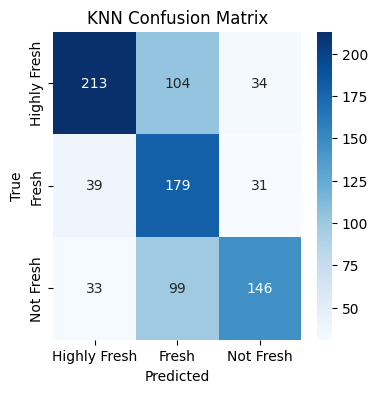

              precision    recall  f1-score   support

Highly Fresh       0.88      0.96      0.92       351
       Fresh       0.91      0.86      0.88       249
   Not Fresh       0.97      0.90      0.93       278

    accuracy                           0.91       878
   macro avg       0.92      0.91      0.91       878
weighted avg       0.91      0.91      0.91       878

Accuracy: 0.9123006833712984


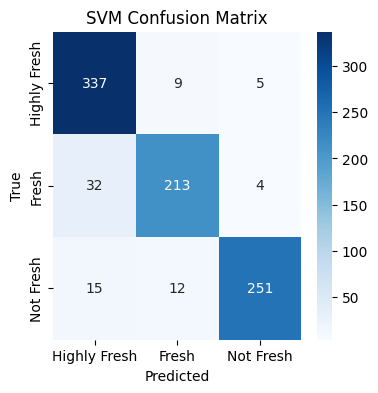

              precision    recall  f1-score   support

Highly Fresh       1.00      1.00      1.00       351
       Fresh       1.00      1.00      1.00       249
   Not Fresh       1.00      1.00      1.00       278

    accuracy                           1.00       878
   macro avg       1.00      1.00      1.00       878
weighted avg       1.00      1.00      1.00       878

Accuracy: 1.0


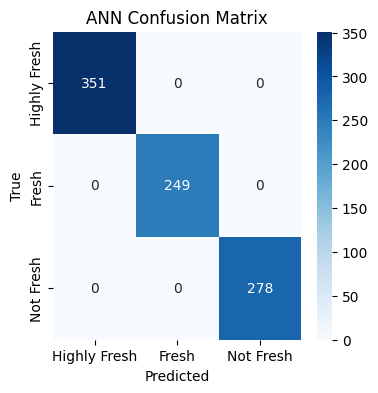

              precision    recall  f1-score   support

Highly Fresh       1.00      1.00      1.00       351
       Fresh       1.00      1.00      1.00       249
   Not Fresh       1.00      1.00      1.00       278

    accuracy                           1.00       878
   macro avg       1.00      1.00      1.00       878
weighted avg       1.00      1.00      1.00       878

Accuracy: 1.0


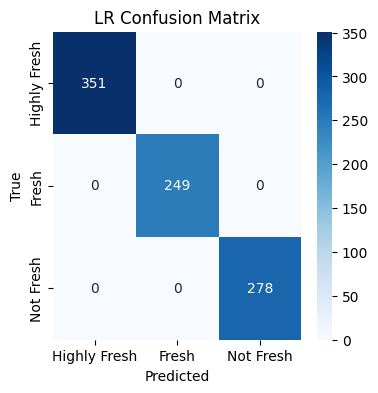

              precision    recall  f1-score   support

Highly Fresh       1.00      1.00      1.00       351
       Fresh       1.00      1.00      1.00       249
   Not Fresh       1.00      1.00      1.00       278

    accuracy                           1.00       878
   macro avg       1.00      1.00      1.00       878
weighted avg       1.00      1.00      1.00       878

Accuracy: 1.0


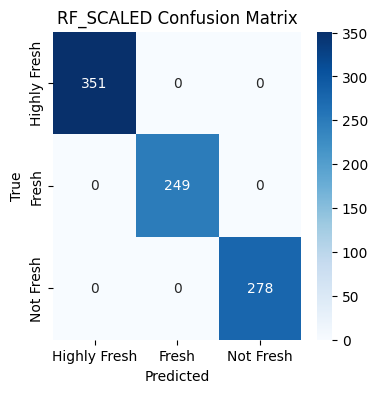

              precision    recall  f1-score   support

Highly Fresh       0.45      0.99      0.62       351
       Fresh       0.77      0.04      0.08       249
   Not Fresh       0.83      0.29      0.43       278

    accuracy                           0.50       878
   macro avg       0.68      0.44      0.38       878
weighted avg       0.66      0.50      0.41       878

Accuracy: 0.4988610478359909


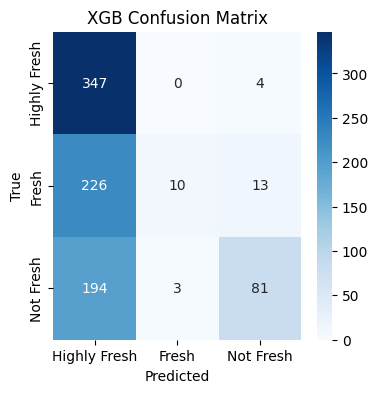

In [ ]:
models = ['knn', 'svm', 'ann', 'lr', 'rf_scaled', 'xgb']
for model in models:
    test_model(model, X, y)

Testing warehouse data

for good N bad folders data

In [ ]:
def create_df3(dataset_folder):
    class_dirs = os.listdir(dataset_folder)
    data = []
    for class_dir in class_dirs:
        # Determine the freshness category based on folder name
        if 'good' in class_dir.lower():
            freshness_label = 'Fresh'
        elif 'bad' in class_dir.lower():
            freshness_label = 'Not Fresh'
        else:
            continue

        image_files = os.listdir(os.path.join(dataset_folder, class_dir))
        for img_name in image_files:
            img_path = os.path.join(dataset_folder, class_dir, img_name)
            data.append((img_path, freshness_label))
    df = pd.DataFrame(data, columns=['img_path', 'class_label'])
    return df

**Indian salmon**

In [ ]:
dataset_folder = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/warehouse_data/cropped_eyes(kartik)/Indian salmon'
df = create_df2(dataset_folder)
df

,img_path,class_label
0,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
1,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
2,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
3,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
4,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
...,...,...
856,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
857,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
858,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
859,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh


In [ ]:
df['class_label'].value_counts()

class_label
Fresh        820
Not Fresh     41
Name: count, dtype: int64

In [ ]:
model_save_path = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models'
os.makedirs(model_save_path, exist_ok=True)
%cd {model_save_path}

/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models


In [ ]:
# Prepare data
X, y = prepare_data(df)
X.shape, y.shape

100%|██████████| 861/861 [17:19<00:00,  1.21s/it]


((861, 4096), (861,))

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.95      0.48      0.64       820
   Not Fresh       0.06      0.15      0.09        41

    accuracy                           0.47       861
   macro avg       0.34      0.21      0.24       861
weighted avg       0.90      0.47      0.61       861

Accuracy: 0.46689895470383275


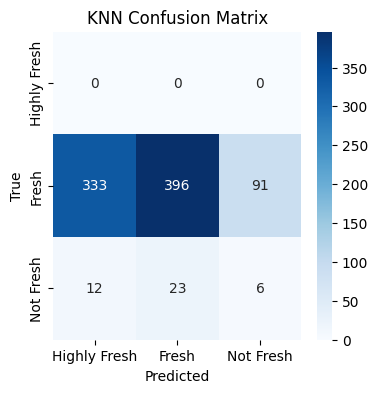

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.96      0.03      0.06       820
   Not Fresh       0.04      0.02      0.03        41

    accuracy                           0.03       861
   macro avg       0.34      0.02      0.03       861
weighted avg       0.92      0.03      0.06       861

Accuracy: 0.0313588850174216


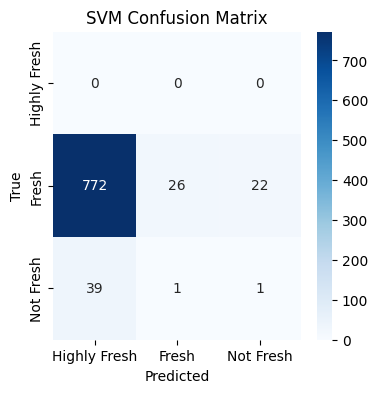

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.96      0.27      0.43       820
   Not Fresh       0.06      0.49      0.10        41

    accuracy                           0.28       861
   macro avg       0.34      0.25      0.18       861
weighted avg       0.92      0.28      0.41       861

Accuracy: 0.2845528455284553


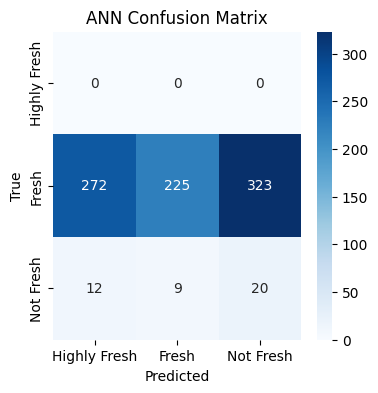

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.95      0.25      0.40       820
   Not Fresh       0.03      0.22      0.06        41

    accuracy                           0.25       861
   macro avg       0.33      0.16      0.15       861
weighted avg       0.90      0.25      0.38       861

Accuracy: 0.2508710801393728


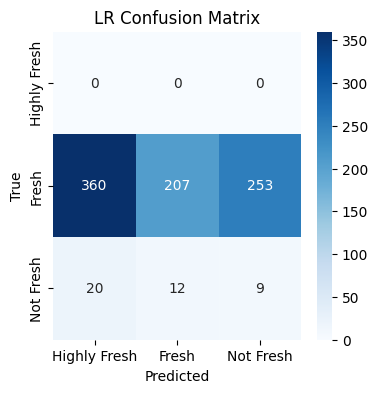

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.97      0.33      0.49       820
   Not Fresh       0.05      0.22      0.08        41

    accuracy                           0.32       861
   macro avg       0.34      0.18      0.19       861
weighted avg       0.93      0.32      0.47       861

Accuracy: 0.32171893147502906


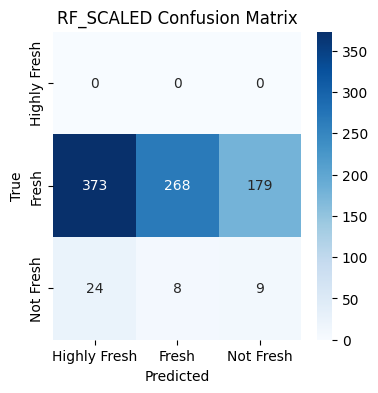

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       1.00      0.04      0.08       820
   Not Fresh       0.04      0.07      0.05        41

    accuracy                           0.04       861
   macro avg       0.35      0.04      0.04       861
weighted avg       0.95      0.04      0.07       861

Accuracy: 0.04065040650406504


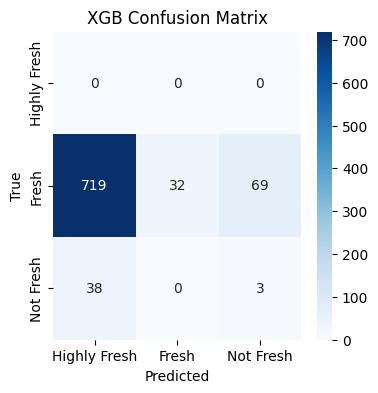

In [ ]:
models = ['knn', 'svm', 'ann', 'lr', 'rf_scaled', 'xgb']
for model in models:
    test_model(model, X, y)

**Tilapia**

In [ ]:
dataset_folder = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/warehouse_data/cropped_eyes(kartik)/Tilapia'
df = create_df2(dataset_folder)
df

,img_path,class_label
0,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
1,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
2,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
3,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
4,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
...,...,...
543,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
544,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
545,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
546,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh


In [ ]:
df['class_label'].value_counts()

class_label
Fresh        523
Not Fresh     25
Name: count, dtype: int64

In [ ]:
model_save_path = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models'
os.makedirs(model_save_path, exist_ok=True)
%cd {model_save_path}

/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models


In [ ]:
# Prepare data
X, y = prepare_data(df)
X.shape, y.shape

100%|██████████| 548/548 [09:01<00:00,  1.01it/s]


((548, 4096), (548,))

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.95      0.50      0.65       523
   Not Fresh       0.03      0.08      0.05        25

    accuracy                           0.48       548
   macro avg       0.33      0.19      0.23       548
weighted avg       0.91      0.48      0.62       548

Accuracy: 0.4762773722627737


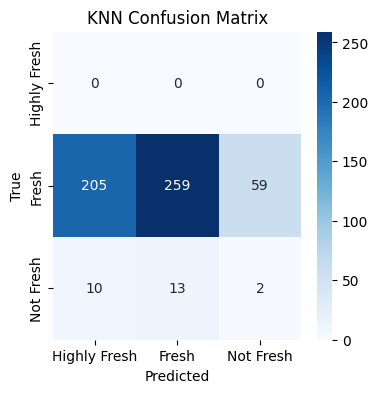

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       1.00      0.05      0.09       523
   Not Fresh       0.04      0.04      0.04        25

    accuracy                           0.05       548
   macro avg       0.35      0.03      0.04       548
weighted avg       0.96      0.05      0.09       548

Accuracy: 0.04744525547445255


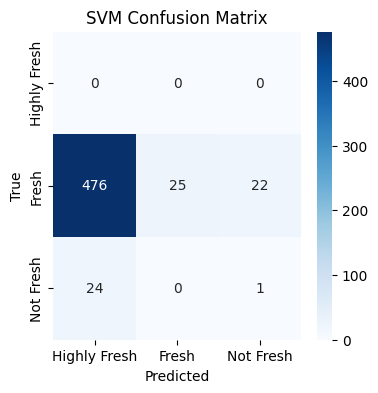

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.98      0.15      0.26       523
   Not Fresh       0.03      0.24      0.05        25

    accuracy                           0.16       548
   macro avg       0.33      0.13      0.10       548
weighted avg       0.93      0.16      0.25       548

Accuracy: 0.15693430656934307


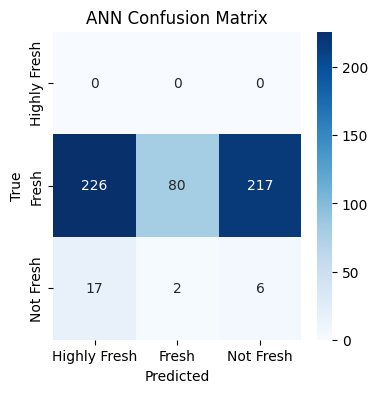

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.95      0.20      0.33       523
   Not Fresh       0.04      0.28      0.07        25

    accuracy                           0.20       548
   macro avg       0.33      0.16      0.13       548
weighted avg       0.91      0.20      0.31       548

Accuracy: 0.20072992700729927


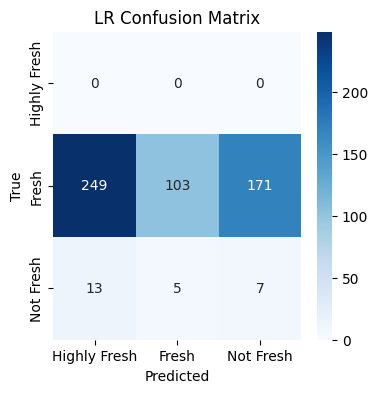

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.94      0.10      0.17       523
   Not Fresh       0.02      0.08      0.03        25

    accuracy                           0.09       548
   macro avg       0.32      0.06      0.07       548
weighted avg       0.90      0.09      0.17       548

Accuracy: 0.0948905109489051


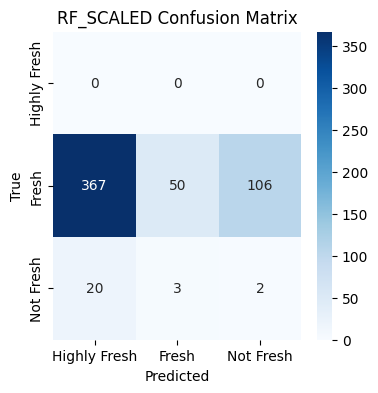

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       1.00      0.00      0.01       523
   Not Fresh       0.00      0.00      0.00        25

    accuracy                           0.00       548
   macro avg       0.33      0.00      0.00       548
weighted avg       0.95      0.00      0.01       548

Accuracy: 0.0036496350364963502


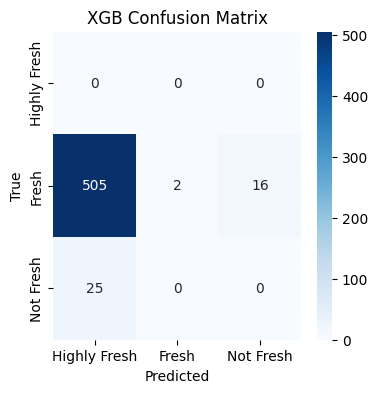

In [ ]:
models = ['knn', 'svm', 'ann', 'lr', 'rf_scaled', 'xgb']
for model in models:
    test_model(model, X, y)

**Mackerel**

In [ ]:
dataset_folder = '/content/drive/MyDrive/Kartik /Mackerel_EYE_TURBIDITY_DATASET/mackerel'
df = create_df3(dataset_folder)
df

,img_path,class_label
0,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Fresh
1,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Fresh
2,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Fresh
3,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Fresh
4,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Fresh
...,...,...
1777,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Not Fresh
1778,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Not Fresh
1779,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Not Fresh
1780,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Not Fresh


In [ ]:
df['class_label'].value_counts()

class_label
Not Fresh    939
Fresh        843
Name: count, dtype: int64

In [ ]:
model_save_path = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models'
os.makedirs(model_save_path, exist_ok=True)
%cd {model_save_path}

/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models


In [ ]:
# Prepare data
X, y = prepare_data(df)
X.shape, y.shape

100%|██████████| 1782/1782 [38:33<00:00,  1.30s/it]


((1782, 4096), (1782,))

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.51      0.56      0.53       843
   Not Fresh       0.54      0.17      0.26       939

    accuracy                           0.36      1782
   macro avg       0.35      0.24      0.27      1782
weighted avg       0.52      0.36      0.39      1782

Accuracy: 0.356341189674523


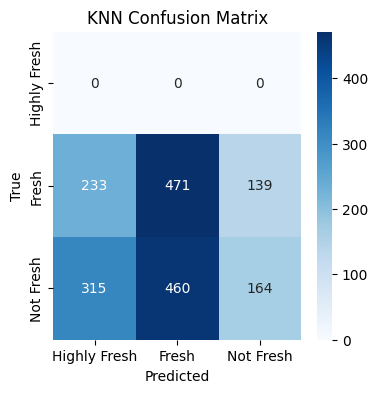

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.38      0.00      0.01       843
   Not Fresh       0.43      0.00      0.01       939

    accuracy                           0.00      1782
   macro avg       0.27      0.00      0.00      1782
weighted avg       0.40      0.00      0.01      1782

Accuracy: 0.003367003367003367


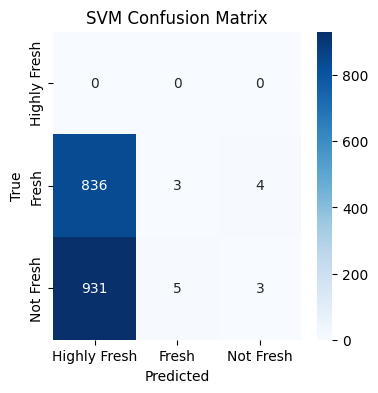

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.58      0.12      0.20       843
   Not Fresh       0.57      0.28      0.37       939

    accuracy                           0.20      1782
   macro avg       0.38      0.13      0.19      1782
weighted avg       0.58      0.20      0.29      1782

Accuracy: 0.2048260381593715


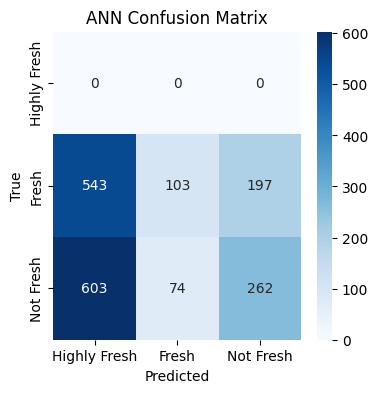

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.53      0.07      0.13       843
   Not Fresh       0.56      0.17      0.26       939

    accuracy                           0.12      1782
   macro avg       0.36      0.08      0.13      1782
weighted avg       0.54      0.12      0.20      1782

Accuracy: 0.12457912457912458


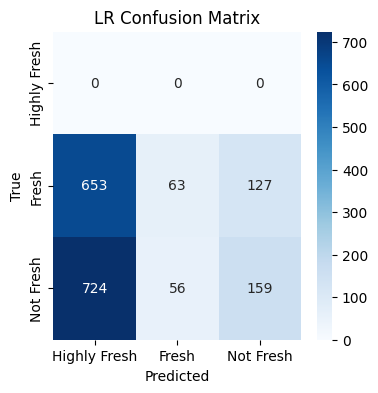

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.45      0.25      0.32       843
   Not Fresh       0.52      0.24      0.33       939

    accuracy                           0.25      1782
   macro avg       0.32      0.17      0.22      1782
weighted avg       0.49      0.25      0.33      1782

Accuracy: 0.24803591470258138


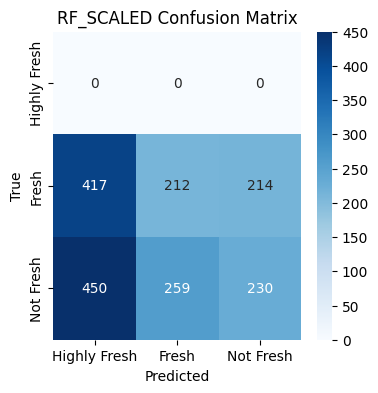

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.38      0.03      0.06       843
   Not Fresh       0.29      0.01      0.02       939

    accuracy                           0.02      1782
   macro avg       0.22      0.01      0.03      1782
weighted avg       0.33      0.02      0.04      1782

Accuracy: 0.020202020202020204


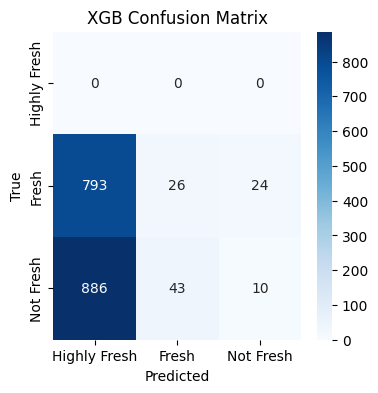

In [ ]:
models = ['knn', 'svm', 'ann', 'lr', 'rf_scaled', 'xgb']
for model in models:
    test_model(model, X, y)

# With Augmentation


## Creating DataFrame

In [ ]:
dataset_folder = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/augmented_data'
df = create_df(dataset_folder)
df

,img_path,class_label
0,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/au...,Fresh
1,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/au...,Fresh
2,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/au...,Fresh
3,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/au...,Fresh
4,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/au...,Fresh
...,...,...
4385,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/au...,Highly Fresh
4386,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/au...,Highly Fresh
4387,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/au...,Highly Fresh
4388,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/au...,Highly Fresh


In [ ]:
df['class_label'].value_counts()

class_label
Highly Fresh    1764
Fresh           1320
Not Fresh       1306
Name: count, dtype: int64

In [ ]:
test_df = df.sample(frac=0.2, random_state=42)
train_df = df.drop(test_df.index)
df.shape, test_df.shape, train_df.shape

((4390, 2), (878, 2), (3512, 2))

In [ ]:
model_save_path = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models/augmented_data'
os.makedirs(model_save_path, exist_ok=True)
%cd {model_save_path}

/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models/augmented_data


## Training

In [ ]:
# Prepare data
X, y = prepare_data(train_df)
X.shape, y.shape

100%|██████████| 3512/3512 [1:09:17<00:00,  1.18s/it]


((3512, 4096), (3512,))

In [ ]:
# Train and save KNN model
knn, scaler_knn = train_knn(X, y, cv=True)
save_model_and_scaler(knn, scaler_knn, 'knn')
print('KNN model saved successfully!')

# Train and save SVM model
svm, scaler_svm = train_svm(X, y, cv=True)
save_model_and_scaler(svm, scaler_svm, 'svm')
print('SVM model saved successfully!')

# Train and save ANN model
ann, scaler_ann = train_ann(X, y, cv=True)
save_model_and_scaler(ann, scaler_ann, 'ann')
print('ANN model saved successfully!')

# Train and save LR model
lr, scaler_lr = train_lr(X, y, cv=True)
save_model_and_scaler(lr, scaler_lr, 'lr')
print('LR model saved successfully!')

# Train and save RF model
rf = train_rf(X, y, cv=True)
joblib.dump(rf, 'rf_model.pkl')
print('RF model saved successfully!')

# Train and save RF model with scaled features
rf, scaler_rf = train_rf_scaled(X, y, cv=True)
save_model_and_scaler(rf, scaler_rf, 'rf_scaled')
print('RF model with scaled features saved successfully!')

# Train and save XGB model
xgb, scaler_xgb = train_xgb(X, y, cv=True)
save_model_and_scaler(xgb, scaler_xgb, 'xgb')
print('XGB model saved successfully!')

print('All models saved successfully!')

              precision    recall  f1-score   support

Highly Fresh       0.63      0.61      0.62       282
       Fresh       0.42      0.55      0.48       215
   Not Fresh       0.59      0.42      0.49       206

    accuracy                           0.54       703
   macro avg       0.55      0.53      0.53       703
weighted avg       0.55      0.54      0.54       703

              precision    recall  f1-score   support

Highly Fresh       0.74      0.69      0.71      1131
       Fresh       0.53      0.70      0.61       856
   Not Fresh       0.76      0.59      0.66       822

    accuracy                           0.66      2809
   macro avg       0.68      0.66      0.66      2809
weighted avg       0.68      0.66      0.66      2809

              precision    recall  f1-score   support

Highly Fresh       0.64      0.56      0.60       283
       Fresh       0.42      0.59      0.50       214
   Not Fresh       0.57      0.44      0.49       206

    accuracy        

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


              precision    recall  f1-score   support

Highly Fresh       0.66      0.83      0.73       282
       Fresh       0.60      0.52      0.56       215
   Not Fresh       0.65      0.51      0.57       206

    accuracy                           0.64       703
   macro avg       0.64      0.62      0.62       703
weighted avg       0.64      0.64      0.63       703

              precision    recall  f1-score   support

Highly Fresh       0.89      0.96      0.92      1131
       Fresh       0.89      0.87      0.88       856
   Not Fresh       0.93      0.87      0.90       822

    accuracy                           0.90      2809
   macro avg       0.91      0.90      0.90      2809
weighted avg       0.90      0.90      0.90      2809



/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


              precision    recall  f1-score   support

Highly Fresh       0.67      0.80      0.73       283
       Fresh       0.55      0.54      0.55       214
   Not Fresh       0.65      0.50      0.56       206

    accuracy                           0.63       703
   macro avg       0.62      0.61      0.61       703
weighted avg       0.63      0.63      0.63       703

              precision    recall  f1-score   support

Highly Fresh       0.89      0.95      0.92      1130
       Fresh       0.89      0.86      0.87       857
   Not Fresh       0.92      0.86      0.89       822

    accuracy                           0.90      2809
   macro avg       0.90      0.89      0.89      2809
weighted avg       0.90      0.90      0.90      2809



...

              precision    recall  f1-score   support

Highly Fresh       0.71      0.70      0.71       283
       Fresh       0.54      0.50      0.52       214
   Not Fresh       0.55      0.61      0.58       205

    accuracy                           0.61       702
   macro avg       0.60      0.60      0.60       702
weighted avg       0.61      0.61      0.61       702

              precision    recall  f1-score   support

Highly Fresh       1.00      1.00      1.00      1130
       Fresh       1.00      1.00      1.00       857
   Not Fresh       1.00      1.00      1.00       823

    accuracy                           1.00      2810
   macro avg       1.00      1.00      1.00      2810
weighted avg       1.00      1.00      1.00      2810



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

Highly Fresh       0.66      0.68      0.67       282
       Fresh       0.49      0.52      0.51       214
   Not Fresh       0.60      0.53      0.56       206

    accuracy                           0.59       702
   macro avg       0.58      0.58      0.58       702
weighted avg       0.59      0.59      0.59       702

              precision    recall  f1-score   support

Highly Fresh       1.00      1.00      1.00      1131
       Fresh       1.00      1.00      1.00       857
   Not Fresh       1.00      1.00      1.00       822

    accuracy                           1.00      2810
   macro avg       1.00      1.00      1.00      2810
weighted avg       1.00      1.00      1.00      2810

Train Accuracy: 0.9999 ± 0.0001
Test Accuracy: 0.6099 ± 0.0163


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LR model saved successfully!
              precision    recall  f1-score   support

Highly Fresh       0.56      0.86      0.68       282
       Fresh       0.60      0.41      0.49       215
   Not Fresh       0.69      0.41      0.52       206

    accuracy                           0.59       703
   macro avg       0.62      0.56      0.56       703
weighted avg       0.61      0.59      0.57       703

              precision    recall  f1-score   support

Highly Fresh       1.00      1.00      1.00      1131
       Fresh       1.00      1.00      1.00       856
   Not Fresh       1.00      1.00      1.00       822

    accuracy                           1.00      2809
   macro avg       1.00      1.00      1.00      2809
weighted avg       1.00      1.00      1.00      2809

              precision    recall  f1-score   support

Highly Fresh       0.60      0.88      0.71       283
       Fresh       0.57      0.45      0.51       214
   Not Fresh       0.71      0.41      0.52   

## Testing

Testing with FFE dataset

In [ ]:
# Prepare data
X, y = prepare_data(test_df)
X.shape, y.shape

100%|██████████| 878/878 [17:28<00:00,  1.19s/it]


((878, 4096), (878,))

              precision    recall  f1-score   support

Highly Fresh       0.65      0.56      0.60       351
       Fresh       0.41      0.57      0.48       249
   Not Fresh       0.62      0.50      0.55       278

    accuracy                           0.54       878
   macro avg       0.56      0.54      0.54       878
weighted avg       0.57      0.54      0.55       878

Accuracy: 0.5444191343963554


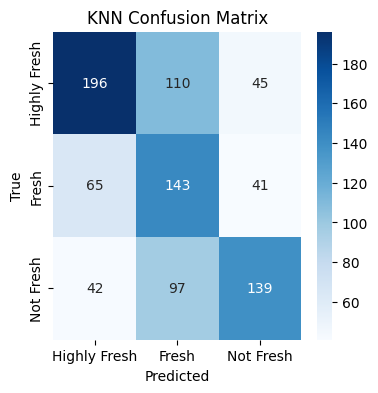

              precision    recall  f1-score   support

Highly Fresh       0.65      0.82      0.73       351
       Fresh       0.57      0.50      0.53       249
   Not Fresh       0.71      0.56      0.62       278

    accuracy                           0.65       878
   macro avg       0.64      0.63      0.63       878
weighted avg       0.65      0.65      0.64       878

Accuracy: 0.6469248291571754


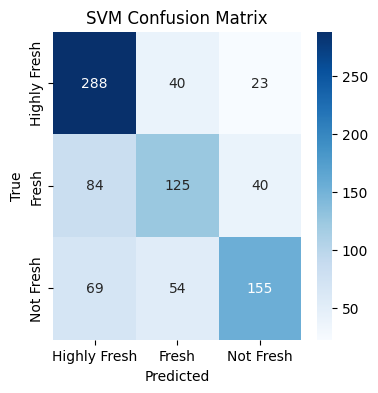

              precision    recall  f1-score   support

Highly Fresh       0.71      0.73      0.72       351
       Fresh       0.53      0.53      0.53       249
   Not Fresh       0.66      0.63      0.65       278

    accuracy                           0.64       878
   macro avg       0.63      0.63      0.63       878
weighted avg       0.64      0.64      0.64       878

Accuracy: 0.643507972665148


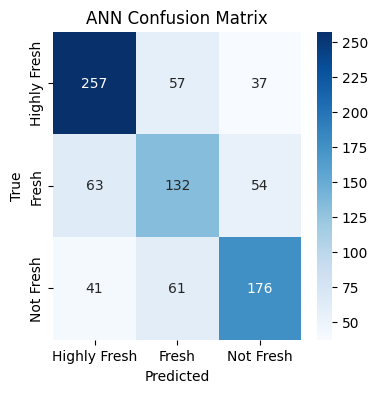

              precision    recall  f1-score   support

Highly Fresh       0.69      0.69      0.69       351
       Fresh       0.47      0.49      0.48       249
   Not Fresh       0.64      0.62      0.63       278

    accuracy                           0.61       878
   macro avg       0.60      0.60      0.60       878
weighted avg       0.61      0.61      0.61       878

Accuracy: 0.6104783599088838


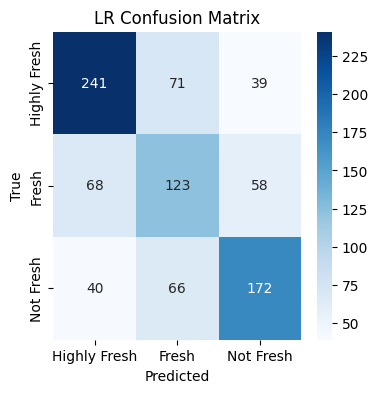

              precision    recall  f1-score   support

Highly Fresh       0.57      0.85      0.69       351
       Fresh       0.51      0.37      0.43       249
   Not Fresh       0.74      0.47      0.57       278

    accuracy                           0.59       878
   macro avg       0.61      0.56      0.56       878
weighted avg       0.61      0.59      0.58       878

Accuracy: 0.5945330296127562


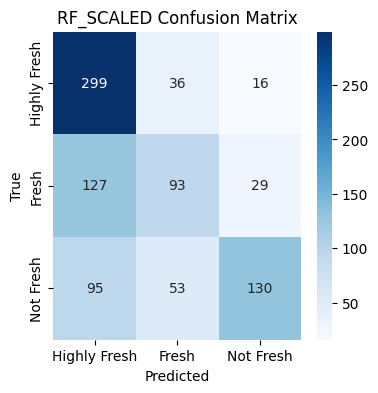

              precision    recall  f1-score   support

Highly Fresh       0.43      0.99      0.60       351
       Fresh       0.57      0.05      0.09       249
   Not Fresh       0.87      0.19      0.31       278

    accuracy                           0.47       878
   macro avg       0.62      0.41      0.33       878
weighted avg       0.61      0.47      0.36       878

Accuracy: 0.46697038724373574


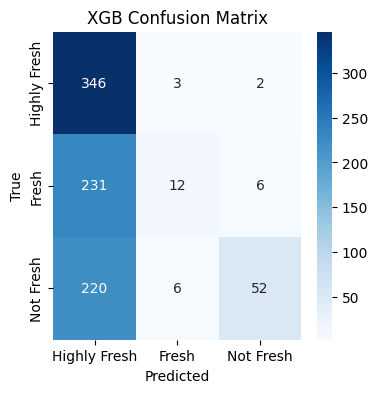

In [ ]:
models = ['knn', 'svm', 'ann', 'lr', 'rf_scaled', 'xgb']
for model in models:
    test_model(model, X, y)

Testing warehouse data

for Highly Fresh, Fresh, Not Fresh folders

In [ ]:
def create_df2(dataset_folder):
    data = []
    for class_dir in os.listdir(dataset_folder):
        # Check if the class is one of the classes you trained on
        if class_dir in class_mapping:
            class_path = os.path.join(dataset_folder, class_dir)
            # List all image files in the class directory
            image_files = os.listdir(class_path)
            for img_name in image_files:
                img_path = os.path.join(class_path, img_name)
                data.append((img_path, class_dir))
    df = pd.DataFrame(data, columns=['img_path', 'class_label'])
    return df

for good N bad folders data

**Indian salmon**

In [ ]:
dataset_folder = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/warehouse_data/cropped_eyes(kartik)/Indian salmon'
df = create_df2(dataset_folder)
df

,img_path,class_label
0,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
1,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
2,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
3,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
4,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
...,...,...
856,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
857,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
858,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
859,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh


In [ ]:
df['class_label'].value_counts()

class_label
Fresh        820
Not Fresh     41
Name: count, dtype: int64

In [ ]:
model_save_path = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models/augmented_data'
os.makedirs(model_save_path, exist_ok=True)
%cd {model_save_path}

/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models/augmented_data


In [ ]:
# Prepare data
X, y = prepare_data(df)
X.shape, y.shape

100%|██████████| 861/861 [13:40<00:00,  1.05it/s]


((861, 4096), (861,))

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.95      0.45      0.61       820
   Not Fresh       0.03      0.20      0.05        41

    accuracy                           0.43       861
   macro avg       0.33      0.21      0.22       861
weighted avg       0.90      0.43      0.58       861

Accuracy: 0.4332171893147503


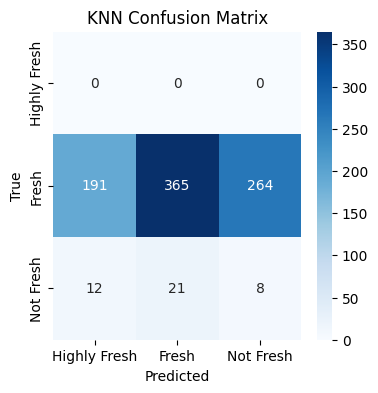

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.91      0.02      0.05       820
   Not Fresh       0.00      0.00      0.00        41

    accuracy                           0.02       861
   macro avg       0.30      0.01      0.02       861
weighted avg       0.87      0.02      0.05       861

Accuracy: 0.023228803716608595


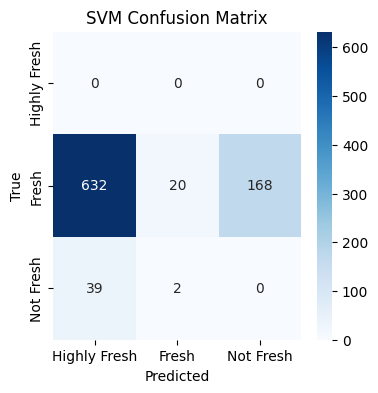

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.94      0.18      0.30       820
   Not Fresh       0.04      0.54      0.08        41

    accuracy                           0.20       861
   macro avg       0.33      0.24      0.13       861
weighted avg       0.90      0.20      0.29       861

Accuracy: 0.19744483159117304


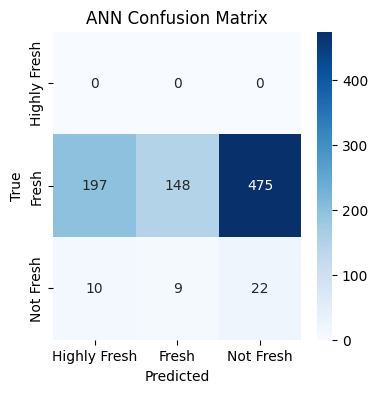

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.94      0.22      0.36       820
   Not Fresh       0.03      0.29      0.05        41

    accuracy                           0.22       861
   macro avg       0.32      0.17      0.14       861
weighted avg       0.89      0.22      0.34       861

Accuracy: 0.22415795586527293


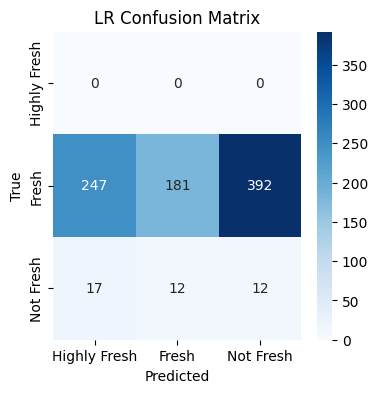

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.97      0.28      0.43       820
   Not Fresh       0.01      0.07      0.02        41

    accuracy                           0.27       861
   macro avg       0.33      0.12      0.15       861
weighted avg       0.92      0.27      0.41       861

Accuracy: 0.2706155632984901


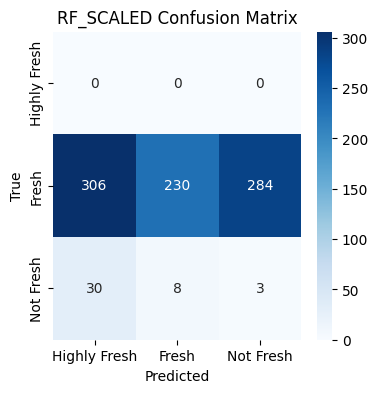

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       1.00      0.02      0.05       820
   Not Fresh       0.00      0.00      0.00        41

    accuracy                           0.02       861
   macro avg       0.33      0.01      0.02       861
weighted avg       0.95      0.02      0.04       861

Accuracy: 0.022067363530778164


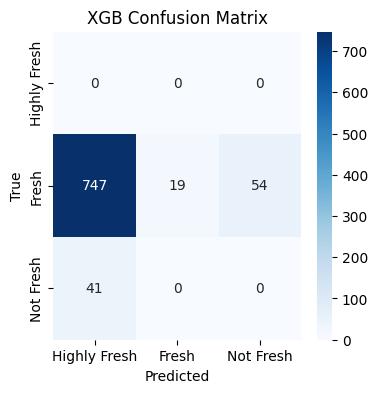

In [ ]:
models = ['knn', 'svm', 'ann', 'lr', 'rf_scaled', 'xgb']
for model in models:
    test_model(model, X, y)

**Tilapia**

In [ ]:
dataset_folder = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/warehouse_data/cropped_eyes(kartik)/Tilapia'
df = create_df2(dataset_folder)
df

,img_path,class_label
0,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
1,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
2,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
3,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
4,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Fresh
...,...,...
543,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
544,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
545,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh
546,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,Not Fresh


In [ ]:
df['class_label'].value_counts()

class_label
Fresh        523
Not Fresh     25
Name: count, dtype: int64

In [ ]:
model_save_path = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models'
os.makedirs(model_save_path, exist_ok=True)
%cd {model_save_path}

/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models


In [ ]:
# Prepare data
X, y = prepare_data(df)
X.shape, y.shape

100%|██████████| 548/548 [08:32<00:00,  1.07it/s]


((548, 4096), (548,))

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.95      0.50      0.65       523
   Not Fresh       0.03      0.08      0.05        25

    accuracy                           0.48       548
   macro avg       0.33      0.19      0.23       548
weighted avg       0.91      0.48      0.62       548

Accuracy: 0.4762773722627737


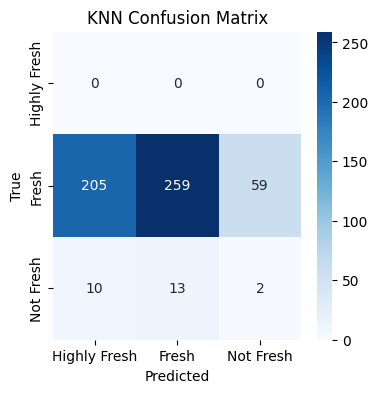

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       1.00      0.05      0.09       523
   Not Fresh       0.04      0.04      0.04        25

    accuracy                           0.05       548
   macro avg       0.35      0.03      0.04       548
weighted avg       0.96      0.05      0.09       548

Accuracy: 0.04744525547445255


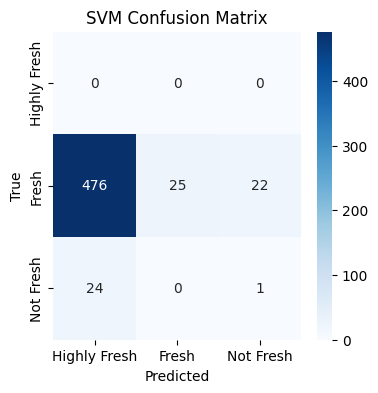

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.98      0.15      0.26       523
   Not Fresh       0.03      0.24      0.05        25

    accuracy                           0.16       548
   macro avg       0.33      0.13      0.10       548
weighted avg       0.93      0.16      0.25       548

Accuracy: 0.15693430656934307


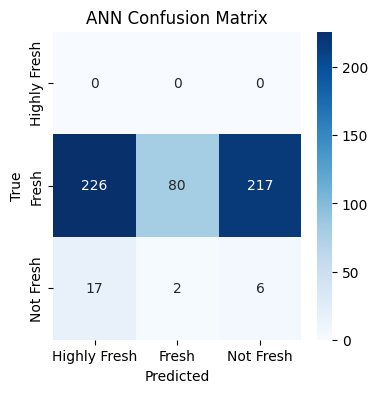

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.95      0.20      0.33       523
   Not Fresh       0.04      0.28      0.07        25

    accuracy                           0.20       548
   macro avg       0.33      0.16      0.13       548
weighted avg       0.91      0.20      0.31       548

Accuracy: 0.20072992700729927


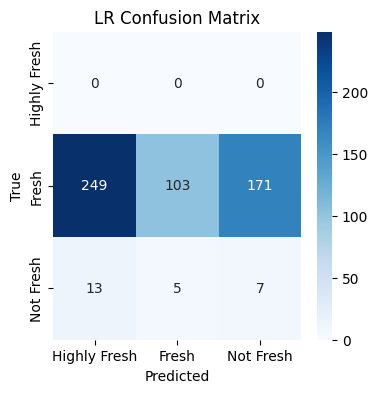

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       0.94      0.10      0.17       523
   Not Fresh       0.02      0.08      0.03        25

    accuracy                           0.09       548
   macro avg       0.32      0.06      0.07       548
weighted avg       0.90      0.09      0.17       548

Accuracy: 0.0948905109489051


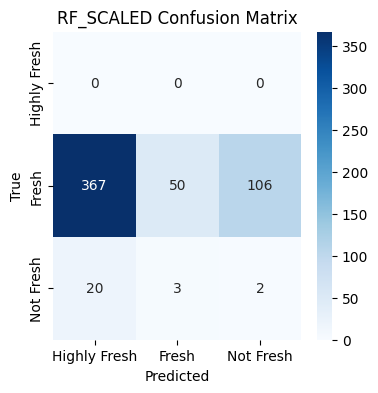

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

Highly Fresh       0.00      0.00      0.00         0
       Fresh       1.00      0.00      0.01       523
   Not Fresh       0.00      0.00      0.00        25

    accuracy                           0.00       548
   macro avg       0.33      0.00      0.00       548
weighted avg       0.95      0.00      0.01       548

Accuracy: 0.0036496350364963502


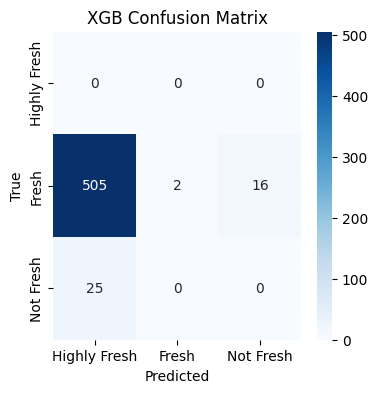

In [ ]:
models = ['knn', 'svm', 'ann', 'lr', 'rf_scaled', 'xgb']
for model in models:
    test_model(model, X, y)

**Mackerel**

In [ ]:
dataset_folder = '/content/drive/MyDrive/Kartik /Mackerel_EYE_TURBIDITY_DATASET/mackerel'
df = create_df3(dataset_folder)
df

,img_path,class_label
0,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Fresh
1,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Fresh
2,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Fresh
3,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Fresh
4,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Fresh
...,...,...
1777,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Not Fresh
1778,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Not Fresh
1779,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Not Fresh
1780,/content/drive/MyDrive/Kartik /Mackerel_EYE_TU...,Not Fresh


In [ ]:
df['class_label'].value_counts()

class_label
Not Fresh    939
Fresh        843
Name: count, dtype: int64

In [ ]:
model_save_path = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models/augmented_data'
os.makedirs(model_save_path, exist_ok=True)
%cd {model_save_path}

/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/VGG19 models/augmented_data


In [ ]:
# Prepare data
X, y = prepare_data(df)
X.shape, y.shape

  0%|          | 6/1782 [00:11<53:30,  1.81s/it]

In [ ]:
models = ['knn', 'svm', 'ann', 'lr', 'rf_scaled', 'xgb']
for model in models:
    test_model(model, X, y)

Test kartik's mackerel eye dataset


In [ ]:
def print_classification_report(confusion_matrix):
    # Extract the values from the confusion matrix
    tp, fn, fp, tn = confusion_matrix.ravel()
    print(f"\ttp: {tp}, fn: {fn}, fp: {fp}, tn: {tn}\n")

    # Create true labels and predicted labels
    true_labels = [0] * (tp + fn) + [1] * (fp + tn)
    predicted_labels = ([0]*tp)+([1]*fn)+([0]*fp)+([1]*tn)

    # Generate the classification report
    report = classification_report(true_labels, predicted_labels,
                                   target_names=["Good", "Bad"],
                                   zero_division=1)
    # Print the classification report
    print(report)

def visualize_confusion_matrix(confusion_matrix):
    # Visualize the confusion matrix
    plt.figure(figsize=(4, 4))
    sns.set(font_scale=1.2)
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
                # xticklabels=['White Head', 'Red Head'], yticklabels=['White Head', 'Red Head']),
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
# Example usage:
# confusion_matrix = np.array([[tp, fn], [fp, tn]])  # Your input with positive class first
tp = 349+293
fn = 201
fp = 350+302
tn = 287
confusion_matrix = np.array([[tp, fn], [fp, tn]])

print_classification_report(confusion_matrix)
visualize_confusion_matrix(confusion_matrix)

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def print_classification_report(confusion_matrix):
    # Create true labels and predicted labels based on the confusion matrix
    true_labels = []
    predicted_labels = []

    for i in range(len(confusion_matrix)):
        for j in range(len(confusion_matrix[i])):
            true_labels.extend([i] * confusion_matrix[i][j])
            predicted_labels.extend([j] * confusion_matrix[i][j])

    # Generate the classification report
    report = classification_report(true_labels, predicted_labels,
                                   target_names=["Highly Fresh", "Fresh", "Not Fresh"],
                                   zero_division=1)
    # Print the classification report
    print(report)

def visualize_confusion_matrix(confusion_matrix):
    # Visualize the confusion matrix
    plt.figure(figsize=(4, 4))
    sns.set(font_scale=0.8)
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['Highly Fresh', 'Fresh', 'Not Fresh'],
                yticklabels=['Highly Fresh', 'Fresh', 'Not Fresh'])
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

# Example usage for 3-class classification
confusion_matrix = np.array([[30, 5, 2], [4, 40, 6], [3, 7, 35]])  # This is just a sample confusion matrix
confusion_matrix = np.array([
[0, 0, 0], # True Highly Fresh
[100, 574, 169], # True Fresh
[150, 226, 563] # True Not Fresh
])
print_classification_report(confusion_matrix)
visualize_confusion_matrix(confusion_matrix)


In [ ]:
def print_classification_report(confusion_matrix):
    # Extract the values from the confusion matrix
    tp, fn, fp, tn = confusion_matrix.ravel()
    print(f"\ttp: {tp}, fn: {fn}, fp: {fp}, tn: {tn}\n")

    # Create true labels and predicted labels
    true_labels = [0] * (tp + fn) + [1] * (fp + tn)
    predicted_labels = ([0]*tp)+([1]*fn)+([0]*fp)+([1]*tn)

    # Generate the classification report
    report = classification_report(true_labels, predicted_labels,
                                   target_names=["Good", "Bad"],
                                   zero_division=1)
    # Print the classification report
    print(report)

def visualize_confusion_matrix(confusion_matrix):
    # Visualize the confusion matrix
    plt.figure(figsize=(3, 3))
    sns.set(font_scale=1)
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
                # xticklabels=['White Head', 'Red Head'], yticklabels=['White Head', 'Red Head']),
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
# Example usage:
# confusion_matrix = np.array([[tp, fn], [fp, tn]])  # Your input with positive class first
tp = 674
fn = 169
fp = 150+226
tn = 563
confusion_matrix = np.array([[tp, fn], [fp, tn]])

print_classification_report(confusion_matrix)
visualize_confusion_matrix(confusion_matrix)